In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("round1.csv")

In [21]:
# df.columns = df.columns.str.strip().str.replace("listed_in(city)","City_List" ).str.lower()

In [64]:
# df

In [23]:
df.drop_duplicates(inplace=True)

In [24]:
df.dropna()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,cost_for_two,reviews_list,cuisines_count,service_type,city_list
0,"Address_874, Bangalore",KFC,No,Yes,3.8,2005,080-1914394,Indiranagar,Bakery,Biryani,"Mexican, Thai, Chinese, Desserts",600,Sample Review Text...,4,Delivery,Bengaluru
1,"Address_511, Bangalore",Resto_511,No,No,3.4,1731,080-2396415,MG Road,Bar,Dosa,"Desserts, North Indian",1500,Sample Review Text...,2,Buffet,Bengaluru
3,"Address_96, Bangalore",Pizza Hut,Yes,Yes,3.2,2101,080-4959345,Jayanagar,Casual Dining,Sushi,"Fast Food, Desserts",200,Sample Review Text...,2,Drinks & nightlife,Bengaluru
4,"Address_759, Bangalore",Resto_759,Yes,Yes,4.7,665,080-5449004,Koramangala,Bakery,Sushi,"Continental, Mexican","1,200",Sample Review Text...,2,Delivery,Bengaluru
5,"Address_109, Bangalore",Resto_109,No,No,2.8,2552,080-6688907,Indiranagar,Cafe,Sushi,Mexican,1200,Sample Review Text...,1,Dine-out,Bengaluru
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,"Address_459, Bangalore",Burger King,Yes,No,2.1,1790,080-2527147,Jayanagar,Bakery,Pizza,Beverages,1200,Sample Review Text...,1,Delivery,Bengaluru
1046,"Address_948, Bangalore",Onesta,Yes,No,3.2,2515,080-5493117,Marathahalli,Pub,Biryani,"North Indian, Beverages, South Indian",600,Sample Review Text...,3,Delivery,Bengaluru
1047,"Address_226, Bangalore",Nandhana Palace,No,Yes,3.3,1396,080-8937865,JP Nagar,Bar,Sushi,Italian,2000,Sample Review Text...,1,Pubs and bars,Bengaluru
1048,"Address_532, Bangalore",Burger King,Yes,No,2.3,1624,080-8467845,Marathahalli,Quick Service Restaurant,Sushi,"South Indian, Mexican, Chinese, Beverages, Ita...",1500,Sample Review Text...,5,Delivery,Bengaluru


In [25]:
df['rate'] = df['rate'].astype(str).str.strip()

In [26]:
df['rate'] = df['rate'].str.replace('/5', '', regex=False)

In [27]:
df = df[df['rate'] != 'NEW']
df = df[df['rate'] != '-']

In [28]:
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

In [65]:
# df['rate'].head()
# df['rate'].isnull().sum()

In [30]:
df['cost_for_two'] = pd.to_numeric(df['cost_for_two'], errors='coerce')

In [32]:
df['high_rated'] = df['rate'].apply(lambda x: 1 if x >= 4.0 else 0)

In [48]:
df.to_csv("restaurant_final_cleaned.csv" ,index=False)

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.set_style("whitegrid")

<Figure size 800x500 with 0 Axes>

Text(0.5, 1.0, 'Cost vs Rating')

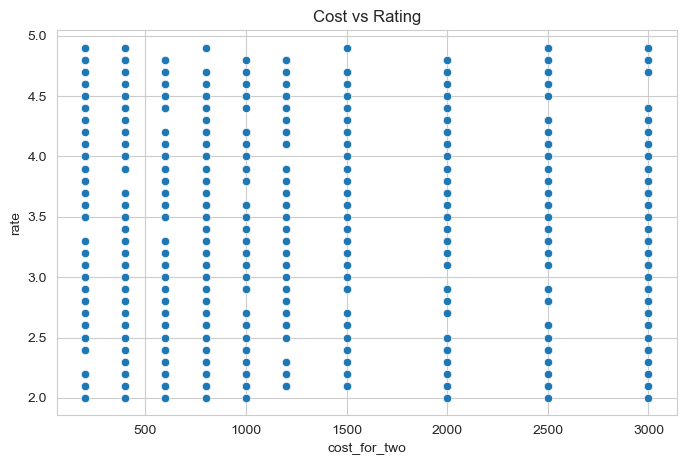

In [51]:
plt.figure(figsize=(8,5))
sns.scatterplot(x = 'cost_for_two', y= 'rate', data =df)
plt.title("Cost vs Rating")

The graph shows that both low-cost and high-cost restaurants can have high ratings.
There is no strong trend showing that higher price lead higher rating.

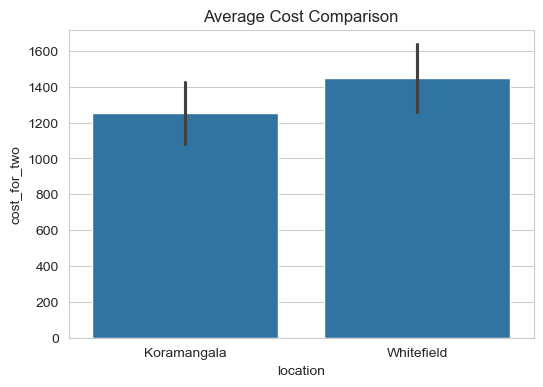

In [52]:
area_df = df[df['location'].isin(['Whitefield','Koramangala'])]

plt.figure(figsize=(6,4))
sns.barplot(x='location', y='cost_for_two', data=area_df)
plt.title("Average Cost Comparison")
plt.show()

The bar charts shows that resturants in Whitefield have a higher average cost for two coompared to karamangala.This suggest that Whitefield provide relatively more premiun dinning options.

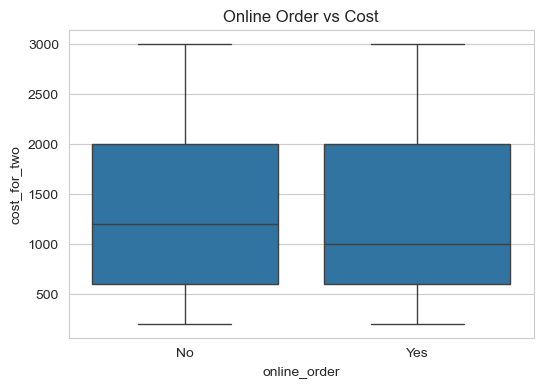

In [53]:
plt.figure(figsize=(6,4))
sns.boxplot(x='online_order', y='cost_for_two', data=df)
plt.title("Online Order vs Cost")
plt.show()

The boxplot shows that there is no significant price difference between restaurants that offer online ordering and those that do not.Overall cost distribution is quiet similar for both categories.

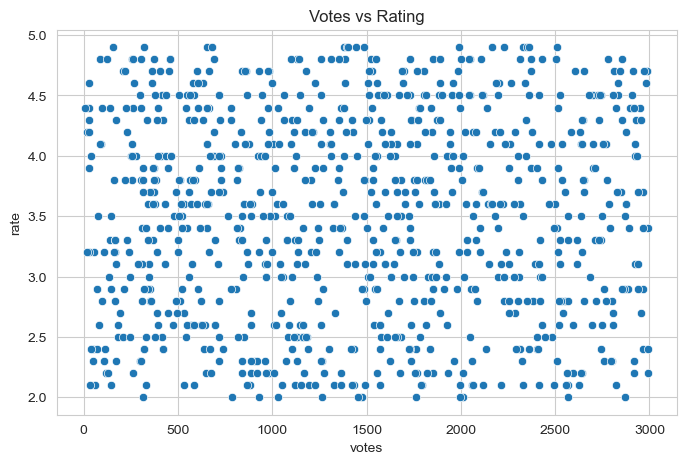

In [54]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='votes', y='rate', data=df)
plt.title("Votes vs Rating")
plt.show()

The scatter plot shows weak relationship between votes and rating. Restaurants with both low and high vote counts can have either high or moderate ratings. While popular restaurants often maintain decent ratings, higher votes do not always mean higher ratings.

In [55]:
df['cuisine_count'] = df['cuisines'].apply(lambda x: len(str(x).split(',')))
df['multi_cuisine'] = df['cuisine_count'].apply(lambda x: "3+ Cuisines" if x>=3 else "1-2 Cuisines")

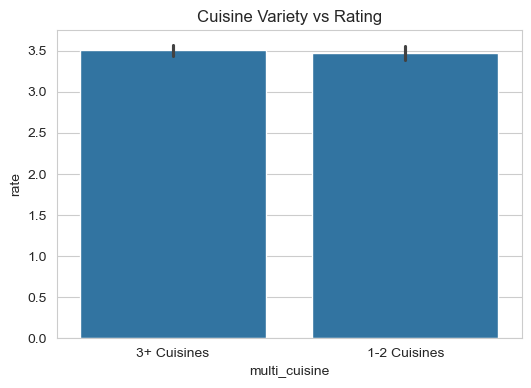

In [56]:
plt.figure(figsize=(6,4))
sns.barplot(x='multi_cuisine', y='rate', data=df)
plt.title("Cuisine Variety vs Rating")
plt.show()

The graph shows minimal difference in raing between multi-cuisine and single-cuisine restaurants.This indicates that serving more cusion does not infulence customer ratings.

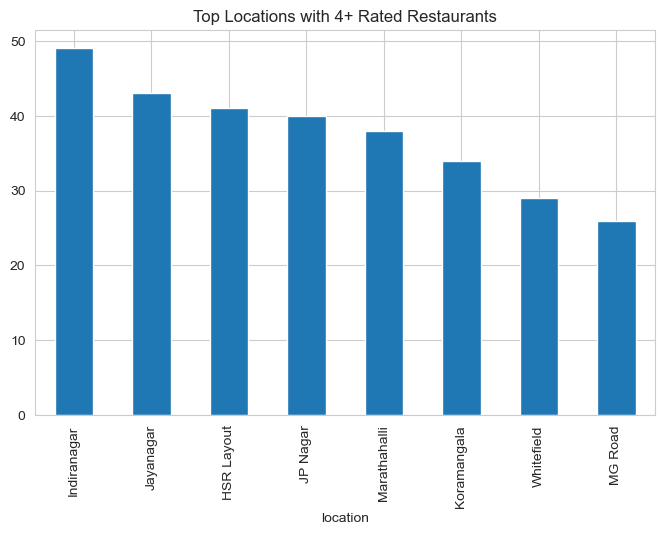

In [57]:
high_rated = df[df['rate'] >= 4.0]
top_locations = high_rated['location'].value_counts().head(10)

plt.figure(figsize=(8,5))
top_locations.plot(kind='bar')
plt.title("Top Locations with 4+ Rated Restaurants")
plt.show()

 Indiranagar has the highest number of restaurents rated 4.0 and above,highlighting it is a major foodie hub.Jayanagar and HSR Layout also show strong presence of highly rated restaurants.This suggest that these areas are popular for quality dining options.

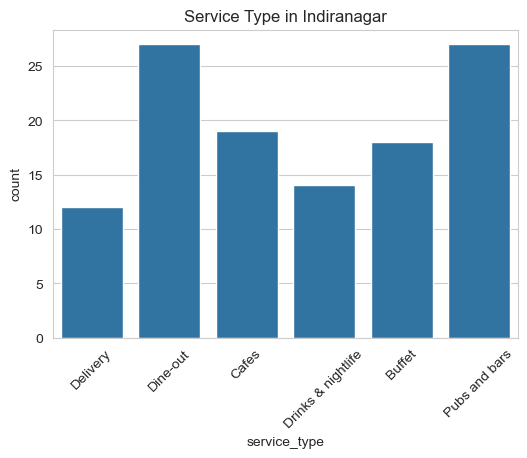

In [58]:
indir = df[df['location'] == 'Indiranagar']

plt.figure(figsize=(6,4))
sns.countplot(x='service_type', data=indir)
plt.xticks(rotation=45)
plt.title("Service Type in Indiranagar")
plt.show()

Indiranagar is more focused on dine-out establishhments and pubs,indicating that it is a major social and nightlife hub. Delivering services are comparatively less than dominant in this location.

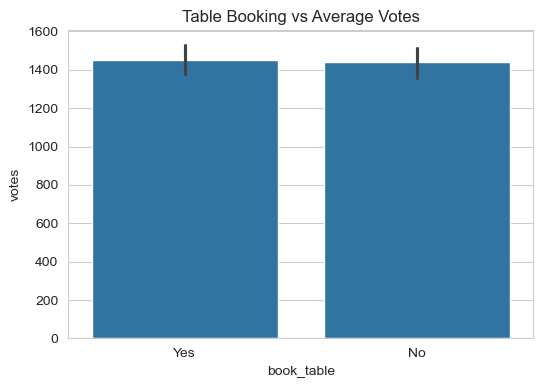

In [59]:
plt.figure(figsize=(6,4))
sns.barplot(x='book_table', y='votes', data=df)
plt.title("Table Booking vs Average Votes")
plt.show()

The average number of vates is very similar for restaurant that allow table booking.
This suggests that table booking availability does not significantly impact engagement.

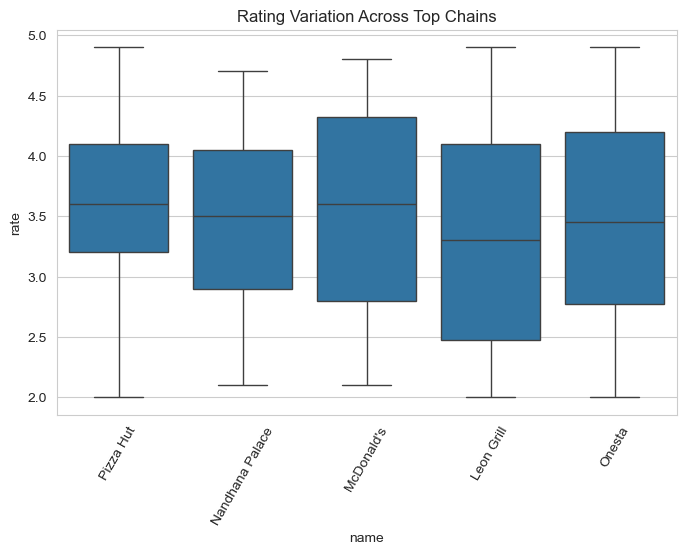

In [60]:
top_chains = df['name'].value_counts().head(5).index
chain_df = df[df['name'].isin(top_chains)]

plt.figure(figsize=(8,5))
sns.boxplot(x='name', y='rate', data=chain_df)
plt.xticks(rotation=60)
plt.title("Rating Variation Across Top Chains")
plt.show()

The boxplot shows noticeable variation in ratings across different branches of the same chain.
And median rating are relatively similar, individual branch performance differs significantly.This shows that customer experience is not entirely consistent across locations.

Final Key Insigts

Expensive restaurants not mean better rated.Many affordable places also receive high raings.

Whitefield appears sightly more expensive than Koramangala,suggesting it may have more premium dinning options.

Offeriing online ordering does not seem to impact how much restaurents charge.

Restaurant with more votes are not necessarily rated higher.Popularity and quality do not always move together.

Indiranagar stands out as a strong dinig hub,with the highest number of highly rated restaurants.

Allowing table booking does not noticeably increase customer engagement in terms of votes.

Even within well-Known chains, ratings vary across branches,Showing that customer experience is not always consistent.